In [1]:
import torch
from transformers import BertForSequenceClassification, AutoTokenizer, pipeline
import requests
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from datetime import datetime, date

# Initialize the sentiment classifier
def initialize_sentiment_analyzer():
    model = BertForSequenceClassification.from_pretrained(
        "StephanAkkerman/FinTwitBERT-sentiment",
        num_labels=3,
        id2label={0: "neutral", 1: "positive", 2: "negative"},
        label2id={"neutral": 0, "positive": 1, "negative": 2},
    )
    model.eval()

    tokenizer = AutoTokenizer.from_pretrained("StephanAkkerman/FinTwitBERT-sentiment")

    sentiment_classifier = pipeline(
        "text-classification",
        model=model,
        tokenizer=tokenizer,
        device=0 if torch.cuda.is_available() else -1,
        return_all_scores=True  # This ensures consistent output format
    )
    return sentiment_classifier

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Initialize the analyzer
print("Initializing sentiment analyzer...")
sentiment_classifier = initialize_sentiment_analyzer()

# Function to fetch messages from StockTwits API
def fetch_stocktwits_messages(symbol, max_messages=30):
    base_url = f"https://api.stocktwits.com/api/2/streams/symbol/{symbol}.json"
    messages = []

    try:
        print(f"Fetching messages for {symbol}...")
        response = requests.get(base_url, headers={'User-Agent': 'Mozilla/5.0'})
        response.raise_for_status()
        data = response.json()

        for msg in data.get('messages', [])[:max_messages]:
            messages.append({
                'id': msg['id'],
                'body': msg['body'],
                'created_at': msg['created_at'],
                'user': msg['user']['username']
            })

    except Exception as e:
        print(f"Error fetching messages: {e}")

    return messages

Initializing sentiment analyzer...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [5]:
# Function to analyze sentiment of a single message
def analyze_single_message(text):
    try:
        results = sentiment_classifier(text)
        # The pipeline returns a list of dicts for each label when return_all_scores=True
        sentiment_scores = {result['label']: result['score'] for result in results[0]}
        predicted_sentiment = max(sentiment_scores.items(), key=lambda x: x[1])[0]
        return predicted_sentiment, sentiment_scores
    except Exception as e:
        print(f"Error analyzing message: {e}")
        return "error", {'neutral': 0, 'positive': 0, 'negative': 0}
    
def analyze_messages(messages):
    results = []

    for msg in tqdm(messages, desc="Analyzing sentiment"):
        try:
            text = msg['body']
            sentiment, scores = analyze_single_message(text)

            msg['sentiment'] = sentiment
            msg.update(scores)
            results.append(msg)

        except Exception as e:
            print(f"Error processing message {msg['id']}: {e}")
            msg['sentiment'] = 'error'
            results.append(msg)

    return results

Fetching messages for TSLA...

Analyzing 30 messages...


Analyzing sentiment: 100%|██████████| 30/30 [00:03<00:00,  8.69it/s]



Sample of analyzed messages:
                   datetime                  user sentiment  \
0 2025-04-22 21:35:27+00:00            blackout23  positive   
1 2025-04-22 21:35:26+00:00              Bobby427  positive   
2 2025-04-22 21:35:24+00:00             xbrett_88   neutral   
3 2025-04-22 21:35:23+00:00  TeslaBagHodlerNoMore  negative   
4 2025-04-22 21:35:23+00:00         Bounced_Check  negative   

                                                body  
0               $TSLA they missed and it goes up lol  
1  $TSLA I can’t wait for him to combine Tesla an...  
2  $TSLA who could have ever guessed that Daddy T...  
3  $TSLA \n\nThey will run this to 275 to burn pu...  
4  $TSLA I knew I should’ve bought yesterday. Eh....  

Sentiment Distribution:
sentiment
negative    16
positive    10
neutral      4
Name: count, dtype: int64


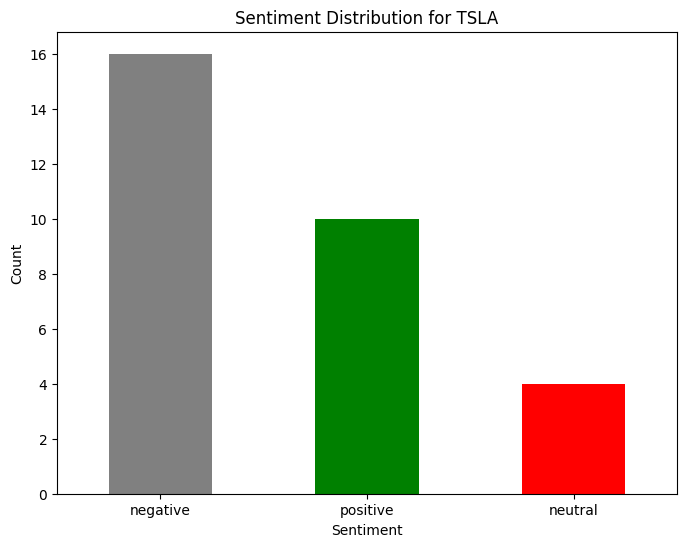

In [6]:
# Main analysis
def main():
    stock_symbol = "TSLA"  # Change to any stock symbol
    messages = fetch_stocktwits_messages(stock_symbol)

    if not messages:
        print("No messages fetched from StockTwits API")
        return

    print(f"\nAnalyzing {len(messages)} messages...")
    analyzed_messages = analyze_messages(messages)

    # Convert to DataFrame for analysis
    df = pd.DataFrame(analyzed_messages)

    # Convert created_at to datetime
    df['datetime'] = pd.to_datetime(df['created_at'])
    df['date'] = df['datetime'].dt.date

    # Show sample of results
    print("\nSample of analyzed messages:")
    print(df[['datetime', 'user', 'sentiment', 'body']].head())

    # Sentiment distribution
    sentiment_counts = df['sentiment'].value_counts()
    print("\nSentiment Distribution:")
    print(sentiment_counts)

    # Plot sentiment distribution
    plt.figure(figsize=(8, 6))
    sentiment_counts.plot(kind='bar', color=['gray', 'green', 'red'])
    plt.title(f'Sentiment Distribution for {stock_symbol}')
    plt.xlabel('Sentiment')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()

    # Save results
    #output_file = f'stocktwits_sentiment_{stock_symbol}.csv'
    #df.to_csv(output_file, index=False)
    #print(f"\nResults saved to {output_file}")

if __name__ == "__main__":
    main()

In [10]:
# Fetch messages + analyze sentiment
def fetch_sentiment_df(symbol="TSLA", max_messages=30):
    base_url = f"https://api.stocktwits.com/api/2/streams/symbol/{symbol}.json"
    response = requests.get(base_url, headers={'User-Agent': 'Mozilla/5.0'})
    data = response.json()
    
    rows = []
    for msg in data.get('messages', [])[:max_messages]:
        body = msg['body']
        created_at = datetime.fromisoformat(msg['created_at'].replace("Z", "+00:00")).date()
        
        scores_raw = sentiment_classifier(body)[0]
        scores = {res['label']: res['score'] for res in scores_raw}
        
        row = {
            "body": body,
            "date": created_at,
            "positive": scores.get("positive", 0),
            "neutral": scores.get("neutral", 0),
            "negative": scores.get("negative", 0),
            "net_sentiment": scores.get("positive", 0) - scores.get("negative", 0)
        }
        rows.append(row)
    
    return pd.DataFrame(rows)

# Run it
sentiment_df = fetch_sentiment_df("TSLA", max_messages=30)
sentiment_df

,body,date,positive,neutral,negative,net_sentiment
0,$SPY trumps sweetness making market rip!!!! $T...,2025-04-22,0.431961,0.026053,0.541986,-0.110025
1,$TSLA 😈🫴🏽💹💹💹,2025-04-22,0.661705,0.184575,0.153720,0.507985
2,$TSLA anyone seen this idiot?,2025-04-22,0.032805,0.846837,0.120358,-0.087553
3,$TSLA 300 eom,2025-04-22,0.519143,0.186832,0.294025,0.225118
4,$TSLA 🤡🐷🤡🐷🤡🐷 LoL shorting this pig down to $145,2025-04-22,0.019150,0.000666,0.980184,-0.961034
5,$TSLA SHORTS!!!!,2025-04-22,0.083819,0.007137,0.909045,-0.825226
6,$ENPH $SPY $TSLA markets ripping and Enphase h...,2025-04-22,0.080919,0.003741,0.915340,-0.834420
7,$TSLA \nElon didn&#39;t do nothing. Trump bai...,2025-04-22,0.016863,0.014255,0.968883,-0.952020
8,$TSLA lets goooo,2025-04-22,0.555936,0.426937,0.017127,0.538808
9,$TSLA ENORMOUS MISS!!! BUY BUY BUY,2025-04-22,0.007806,0.001084,0.991110,-0.983305


In [11]:
# Aggregate daily sentiment
daily_sentiment = sentiment_df.groupby('date').agg({
    'neutral': 'mean',
    'positive': 'mean',
    'negative': 'mean'
}).reset_index()

# Add a "net sentiment" score (positive - negative)
daily_sentiment['net_sentiment'] = daily_sentiment['positive'] - daily_sentiment['negative']

daily_sentiment

,date,neutral,positive,negative,net_sentiment
0,2025-04-22,0.172511,0.313058,0.514431,-0.201373
